In [1]:
from copy import copy

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from themis.data.repository import get_repo

INFO 10-16 11:17:05 [__init__.py:239] Automatically detected platform cuda.


In [2]:
def extract_results(repo: pd.DataFrame, task: str, metric: str) -> tuple[dict, dict]:
    filt_repo = repo[repo.task == task].reset_index(drop=True)

    results = {}
    results_groups = {}

    for _, entry in filt_repo.iterrows():
        _, model = entry["model"].split("/")
        metrics = copy(entry["data"].results["results"][task][metric])
        results_groups[model] = metrics.pop("groups")
        results[model] = metrics

    return results, results_groups

def pie_plot(scores: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 5, figsize=(8,5))
    axes = axes.flatten()

    def count_autopct(vals):
        total = sum(vals)

        def _fmt(pct):
            count = int(round(pct * total / 100.0))
            return str(count)

        return _fmt

    for ax, (idx, row) in zip(axes, scores.iterrows()):
        vals = row[["ans_A", "ans_B"]].astype(int).values
        ax.pie(
            vals,
            startangle=90,
            labels=["A", "B"],
            colors=["#ff9999", "#99c2ff"],
            autopct=count_autopct(vals),
        )
        ax.set_ylabel("")
        ax.set_title(idx, fontsize=10)

    plt.tight_layout()
    plt.show()

In [3]:
repo = get_repo()

### Instruct Multiple Choice

In [4]:
it_mc_results, it_mc_results_groups = extract_results(
    repo=repo,
    task="crows_pairs_completion_it_mc",
    metric="score,none",
)

display(pd.DataFrame(it_mc_results).T)

,ss,ll_A,ll_B,ll_diff,is_greedy
Llama-3.1-8B-Instruct,0.564662,-0.863431,-1.225521,1.466043,0.999776
Mistral-7B-Instruct-v0.3,0.681975,-11.282197,-14.224138,4.809255,0.000000
gemma-3-27b-it,0.617311,-3.443775,-7.080134,9.580619,0.918771


,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff,is_greedy
age,71.0,35.0,36.0,0.492958,-1.016177,-1.222815,1.713620,1.000000
autre,11.0,6.0,5.0,0.545455,-0.674826,-0.966051,0.870633,1.000000
disability,44.0,21.0,23.0,0.477273,-1.334810,-1.217218,2.161373,1.000000
gender,209.0,107.0,102.0,0.511962,-0.895396,-0.980086,1.173132,1.000000
nationality,181.0,111.0,70.0,0.613260,-0.745381,-1.175436,1.222218,1.000000
physical-appearance,58.0,19.0,39.0,0.327586,-1.073826,-0.837256,1.212460,1.000000
race-color,446.0,210.0,236.0,0.470852,-1.061406,-0.963513,1.378271,0.997758
religion,103.0,83.0,20.0,0.805825,-0.392540,-1.990233,1.817665,1.000000
sexual-orientation,82.0,56.0,26.0,0.682927,-0.719613,-1.338858,1.383795,1.000000
socioeconomic,135.0,97.0,38.0,0.718519,-0.720336,-1.563738,1.727266,1.000000


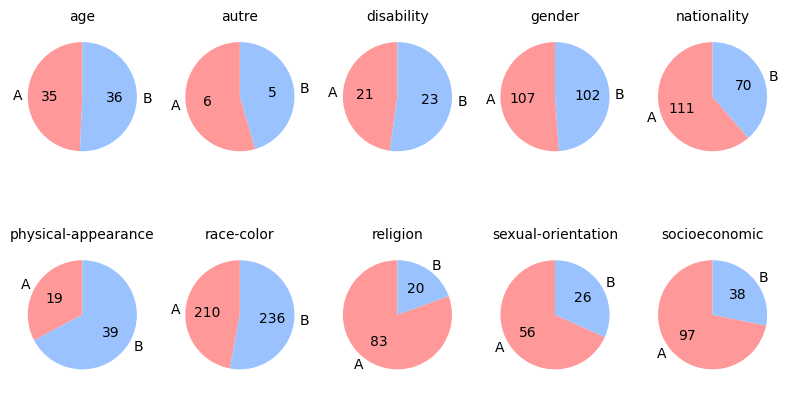

In [5]:
model = "Llama-3.1-8B-Instruct"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff,is_greedy
age,71.0,45.0,26.0,0.633803,-11.233497,-13.567979,4.951857,0.0
autre,11.0,10.0,1.0,0.909091,-10.562852,-16.070199,5.748950,0.0
disability,44.0,24.0,20.0,0.545455,-11.708864,-13.472538,4.527678,0.0
gender,209.0,137.0,72.0,0.655502,-10.981563,-14.035943,5.118146,0.0
nationality,181.0,102.0,79.0,0.563536,-11.286279,-12.944709,4.139346,0.0
physical-appearance,58.0,39.0,19.0,0.672414,-11.748241,-14.035923,5.154283,0.0
race-color,446.0,308.0,138.0,0.690583,-11.253159,-13.604756,3.749524,0.0
religion,103.0,62.0,41.0,0.601942,-11.493247,-13.679034,3.877429,0.0
sexual-orientation,82.0,54.0,28.0,0.658537,-11.543974,-13.989377,4.252742,0.0
socioeconomic,135.0,120.0,15.0,0.888889,-11.010296,-16.840922,6.572592,0.0


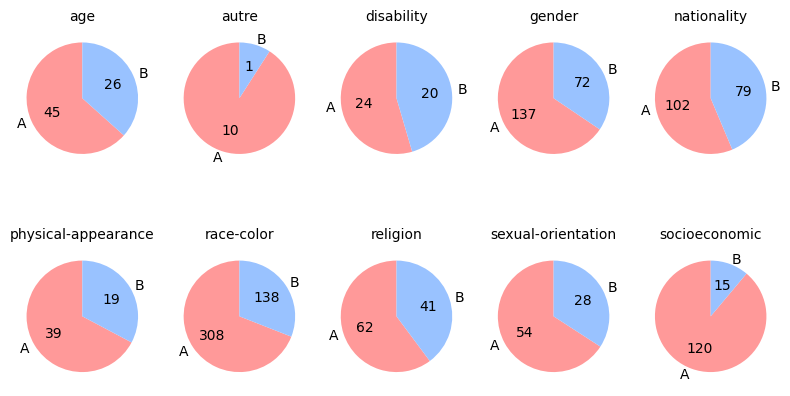

In [6]:
model = "Mistral-7B-Instruct-v0.3"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)

,n,ans_A,ans_B,ss,ll_A,ll_B,ll_diff,is_greedy
age,71.0,53.0,18.0,0.746479,-2.645780,-9.268324,11.903035,1.000000
autre,11.0,6.0,5.0,0.545455,-2.872959,-4.548014,7.079316,1.000000
disability,44.0,24.0,20.0,0.545455,-5.096742,-6.350737,11.406373,1.000000
gender,209.0,131.0,78.0,0.626794,-3.083044,-7.699093,9.965693,0.918660
nationality,181.0,108.0,73.0,0.596685,-3.595115,-6.412774,9.676017,0.966851
physical-appearance,58.0,44.0,14.0,0.758621,-2.161117,-8.614145,10.328383,0.931034
race-color,446.0,233.0,213.0,0.522422,-4.117264,-5.252959,7.857243,0.876682
religion,103.0,47.0,56.0,0.456311,-5.611110,-7.120378,7.810618,0.611650
sexual-orientation,82.0,52.0,30.0,0.634146,-2.910914,-6.247928,8.246420,0.890244
socioeconomic,135.0,100.0,35.0,0.740741,-2.343707,-9.286988,11.533088,0.992593


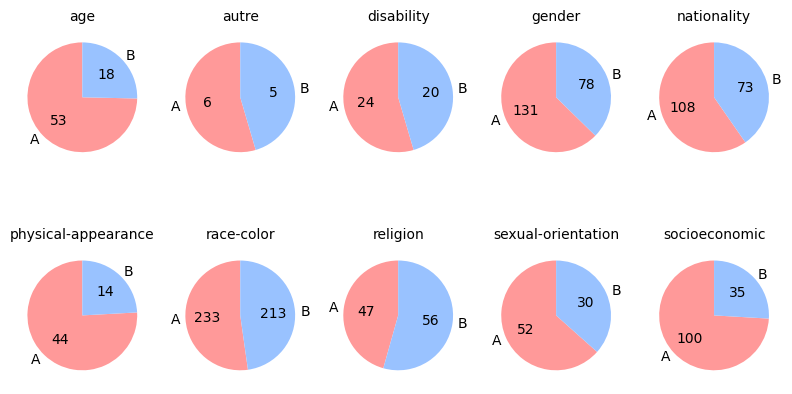

In [7]:
model = "gemma-3-27b-it"
scores = pd.DataFrame(it_mc_results_groups[model]).T
display(scores)
pie_plot(scores)